# EDA

#### Step 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

These libraries are used for loading the Excel dataset, cleaning data, calculating summary statistics, and creating visualizations.

#### Step 2. Load Dataset

In [26]:
df = pd.read_excel(
    "overall_mri_full_clean.xlsx",
    sheet_name="MRI_Table"
)

print(df.shape)
print(df.head())

(66, 74)
  Participant ID Modality Status  Shape X  Shape Y  Shape Z  Total Voxels  \
0          RS001      T1w     ok    144.0    256.0    256.0     9437184.0   
1          RS001      T2w     ok    320.0    320.0     30.0     3072000.0   
2          RS002      T1w     ok    144.0    256.0    256.0     9437184.0   
3          RS002      T2w     ok    320.0    320.0     26.0     2662400.0   
4          RS003      T1w     ok    144.0    256.0    256.0     9437184.0   

   Voxel Size X mm  Voxel Size Y mm  Voxel Size Z mm  ...  Affine 2 4  \
0          1.20000         0.976562         0.976562  ... -104.023438   
1          0.71875         0.718750         6.000000  ...  -88.369110   
2          1.20000         0.976562         0.976562  ... -124.023438   
3          0.68750         0.687500         6.000000  ...  -98.611305   
4          1.20000         0.976562         0.976562  ...  -85.414795   

   Affine 3 1    Affine 3 2  Affine 3 3  Affine 3 4  Affine 4 1  Affine 4 2  \
0    0.000

This loads the MRI_Table sheet from the Excel file. The shape shows the number of rows and columns in the dataset. Initially, the dataset contains 66 MRI records and 74 variables.

#### Step 3: Remove Failed MRI Scans

In [29]:
df = df.dropna(subset=["Total Voxels"])

print(df.shape)

(64, 74)



Rows with missing Total Voxels are failed MRI scans. Since Total Voxels is the target variable, those rows cannot be used for modeling. After removing them, the cleaned dataset contains 64 valid MRI scans.


#### Step 4: Dataset Overview

In [30]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 64 entries, 0 to 65
Data columns (total 74 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Participant ID                  64 non-null     object 
 1   Modality                        64 non-null     object 
 2   Status                          64 non-null     object 
 3   Shape X                         64 non-null     float64
 4   Shape Y                         64 non-null     float64
 5   Shape Z                         64 non-null     float64
 6   Total Voxels                    64 non-null     float64
 7   Voxel Size X mm                 64 non-null     float64
 8   Voxel Size Y mm                 64 non-null     float64
 9   Voxel Size Z mm                 64 non-null     float64
 10  Voxel Volume mm3                64 non-null     float64
 11  Image Volume mm3                64 non-null     float64
 12  Image Volume ml                 64 non-null

This shows the data types, number of non-null values, and total columns. The dataset contains 69 numerical variables and 5 categorical variables. Most modeling methods will use the numerical MRI-derived features.

#### Step 5: Missing Value Analysis

In [31]:
missing = df.isnull().sum()

print(missing[missing > 0])

Error Message    64
dtype: int64


This checks whether any missing values remain after cleaning. The only missing column is Error Message, which is empty because the remaining scans were successfully processed.

In [32]:
df = df.drop(columns=["Error Message"], errors="ignore")

print(df.isnull().sum()[df.isnull().sum() > 0])

Series([], dtype: int64)


The Error Message column is removed because it does not provide useful information for EDA or modeling.

#### Step 6: Summary Statistics

In [33]:
summary_stats = df.describe()

print(summary_stats)

          Shape X     Shape Y     Shape Z  Total Voxels  Voxel Size X mm  \
count   64.000000   64.000000   64.000000  6.400000e+01        64.000000   
mean   224.125000  315.500000  245.375000  2.083355e+07         1.008160   
std     61.283494   96.736592  157.559513  2.566580e+07         0.196826   
min    128.000000  256.000000   26.000000  2.662400e+06         0.500000   
25%    192.000000  256.000000   90.000000  5.865472e+06         1.000000   
50%    192.000000  272.000000  256.000000  9.437184e+06         1.000000   
75%    256.000000  288.000000  288.000000  1.592525e+07         1.093750   
max    384.000000  512.000000  512.000000  1.006633e+08         1.450000   

       Voxel Size Y mm  Voxel Size Z mm  Voxel Volume mm3  Image Volume mm3  \
count        64.000000        64.000000         64.000000      6.400000e+01   
mean          0.907294         1.470228          1.418402      1.277141e+07   
std           0.221291         1.182219          0.905625      2.003030e+06   

Summary statistics show the mean, standard deviation, minimum, maximum, and quartiles for numerical variables. For Total Voxels, the mean is about 20.8 million and the median is about 9.4 million, which suggests the target variable is right-skewed.

#### Step 7: Histogram of Target Variable

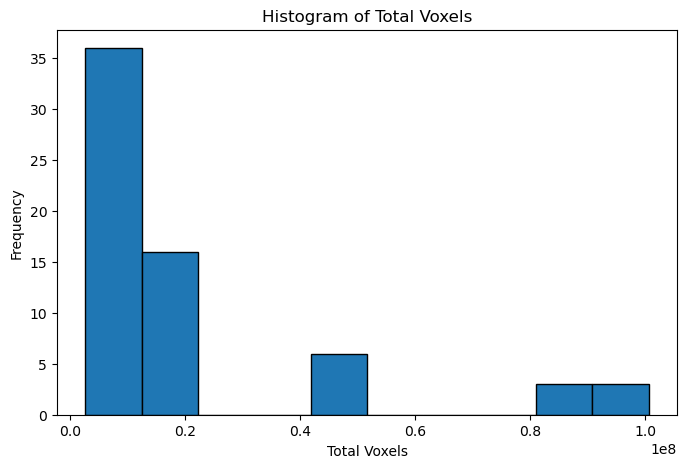

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Total Voxels"],
    bins=10,
    edgecolor="black"
)

plt.title("Histogram of Total Voxels")
plt.xlabel("Total Voxels")
plt.ylabel("Frequency")
plt.show()

The histogram indicates that Total Voxels is positively skewed. Most MRI scans contain relatively small voxel counts, while a few scans have extremely large voxel counts. The long right tail and the difference between the mean (20.8 million) and median (9.4 million) suggest the presence of outliers and non-normality. This justifies the use of regularized regression models and tree-based methods in addition to traditional linear regression.

#### Step 8: Boxplot for Outlier Detection

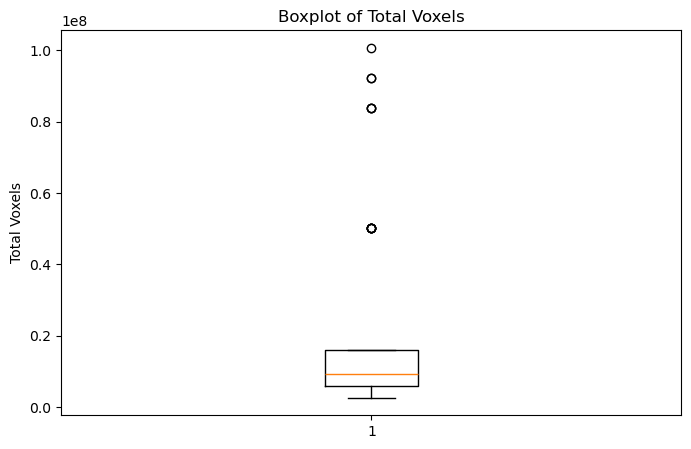

In [35]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Total Voxels"])

plt.title("Boxplot of Total Voxels")
plt.ylabel("Total Voxels")
plt.show()

The boxplot confirms the presence of several extreme high-value MRI scans, indicating a positively skewed distribution with substantial variability in Total Voxels across subjects.

#### Step 9: Correlation Analysis with Target Variable

In [36]:
corr = df.corr(numeric_only=True)

corr_target = corr["Total Voxels"]

print(
    corr_target.sort_values(ascending=False).head(20)
)

Total Voxels                      1.000000
Nonzero Voxels                    0.992995
Approx Brain Voxels               0.989226
Middle Coronal Nonzero Voxels     0.985231
Background Voxels                 0.974385
Middle Sagittal Nonzero Voxels    0.948369
Middle Coronal Index              0.922054
Shape Y                           0.922054
Middle Axial Nonzero Voxels       0.900894
Shape Z                           0.844044
Middle Axial Index                0.843898
Nonzero Percent                   0.512403
Approx Brain Percent Of Image     0.460641
Shape X                           0.418102
Middle Sagittal Index             0.418102
P25 Intensity                     0.384816
P75 Intensity                     0.363315
Affine 1 1                        0.318813
Background Mean Intensity         0.316467
Median Intensity                  0.314815
Name: Total Voxels, dtype: float64


Correlation Analysis

A correlation analysis was performed to identify MRI-derived features that are strongly associated with the response variable, Total Voxels. The results revealed several variables with extremely high positive correlations.

The strongest correlations were observed for Nonzero Voxels (r = 0.993), Approx Brain Voxels (r = 0.989), Middle Coronal Nonzero Voxels (r = 0.985), and Background Voxels (r = 0.974). These variables measure different aspects of voxel counts within MRI images and therefore have a strong direct relationship with the total number of voxels.

Image dimension variables also showed substantial correlations with Total Voxels. Shape Y exhibited a correlation of 0.922, while Shape Z showed a correlation of 0.844. These results indicate that larger MRI image dimensions are associated with higher voxel counts.

Moderate correlations were observed for Nonzero Percent (r = 0.512), Approx Brain Percent of Image (r = 0.461), and Shape X (r = 0.418). Intensity-based variables such as P25 Intensity (r = 0.385), P75 Intensity (r = 0.363), Background Mean Intensity (r = 0.316), and Median Intensity (r = 0.315) exhibited weaker relationships with the response variable.

Overall, voxel-based measurements and image dimensions appear to be the most informative predictors for modeling Total Voxels. The extremely high correlations among several predictors also suggest the presence of multicollinearity, which motivates the use of regularized regression methods such as Ridge Regression, LASSO Regression, and Elastic Net Regression in subsequent analyses.


### Step 10: Correlation Heatmap

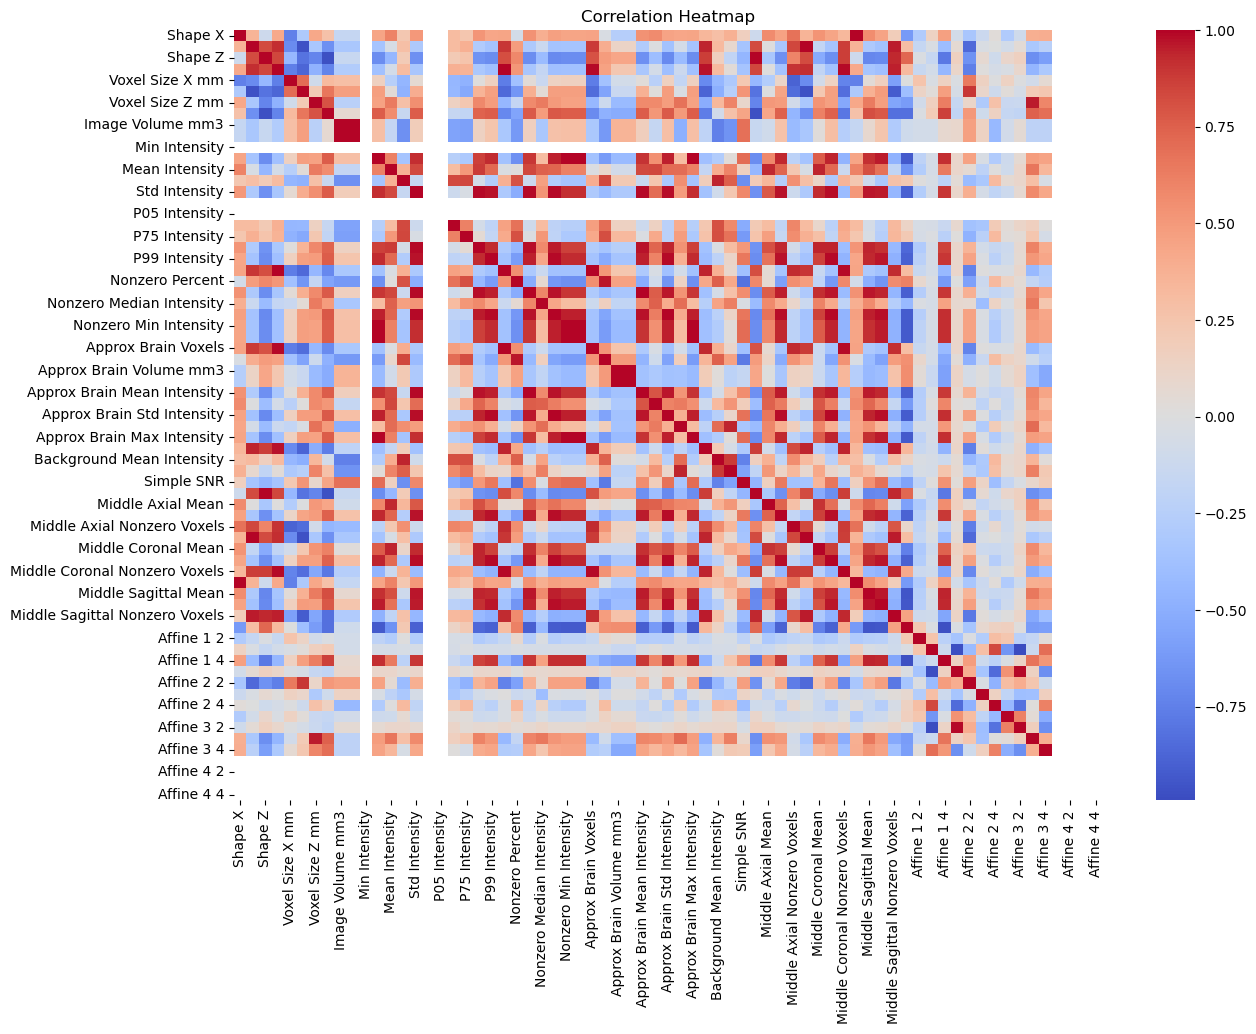

In [37]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

##### Correlation Heatmap

A correlation heatmap was generated to visualize the relationships among all numerical MRI-derived variables. The heatmap uses a color scale ranging from -1 to +1, where dark red indicates a strong positive correlation, dark blue indicates a strong negative correlation, and lighter colors indicate weaker relationships.

Several clusters of strongly correlated variables are visible in the heatmap. In particular, voxel-based measurements such as Total Voxels, Nonzero Voxels, Approx Brain Voxels, Background Voxels, and region-specific voxel counts exhibit strong positive correlations with one another. These variables appear as large red blocks within the heatmap, indicating that they contain similar information related to MRI image size and brain volume.

The heatmap also reveals strong relationships among image dimension variables, including Shape X, Shape Y, and Shape Z, as well as several intensity-based measurements. Conversely, some affine transformation variables display weak correlations with most imaging features, suggesting they contribute less information for predicting Total Voxels.

The presence of numerous highly correlated variables confirms the multicollinearity identified in the VIF analysis. This finding supports the use of regularization techniques such as Ridge Regression, LASSO Regression, and Elastic Net Regression, which are designed to handle highly correlated predictors more effectively than traditional multiple linear regression.

Overall, the heatmap provides visual evidence that voxel-based and brain-volume-related features are likely to be the most important predictors in subsequent modeling stages.


#### Step 11. Scatterplot of Strong Predictor

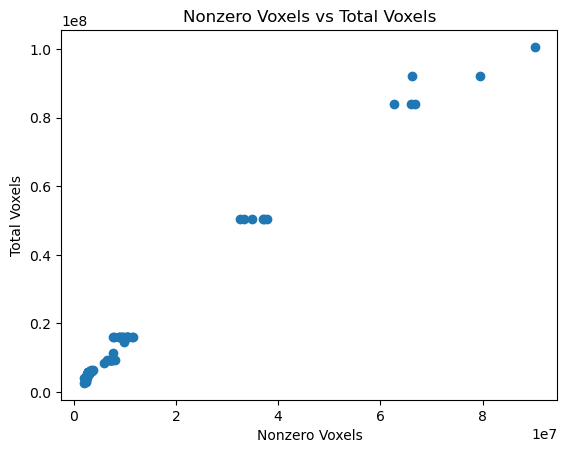

In [38]:
plt.scatter(
    df["Nonzero Voxels"],
    df["Total Voxels"]
)

plt.xlabel("Nonzero Voxels")
plt.ylabel("Total Voxels")
plt.title("Nonzero Voxels vs Total Voxels")
plt.show()

##### Scatter Plot: Nonzero Voxels vs Total Voxels

A scatter plot was created to examine the relationship between Nonzero Voxels and the response variable, Total Voxels. The plot reveals an extremely strong positive linear relationship between the two variables.

As the number of Nonzero Voxels increases, the Total Voxels also increase proportionally. The observations closely follow an upward linear trend with very little dispersion around the trend, indicating a nearly perfect association between the variables.

This visual finding is consistent with the correlation analysis, which reported a correlation coefficient of 0.993 between Nonzero Voxels and Total Voxels. Such a high correlation suggests that Nonzero Voxels is one of the most important predictors of Total Voxels in the dataset.

Several observations with exceptionally large voxel counts are visible in the upper-right portion of the scatter plot. These correspond to the large MRI scans previously identified in the histogram and boxplot analyses. Despite these extreme values, the linear relationship remains strong across the entire range of observations.

Overall, the scatter plot demonstrates that Nonzero Voxels contains substantial predictive information and will likely be a key variable in regression and machine learning models developed during subsequent phases of the project.


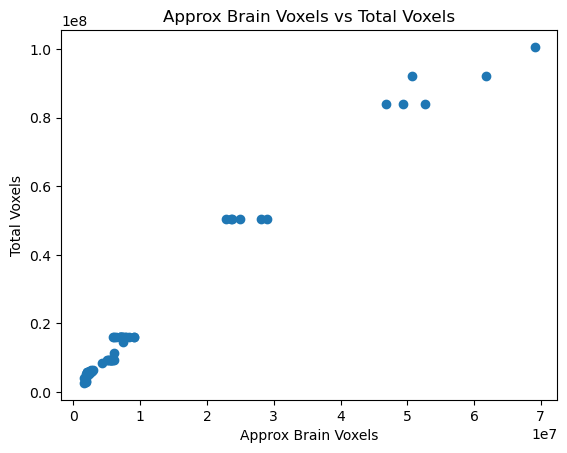

In [39]:
plt.scatter(
    df["Approx Brain Voxels"],
    df["Total Voxels"]
)

plt.xlabel("Approx Brain Voxels")
plt.ylabel("Total Voxels")
plt.title("Approx Brain Voxels vs Total Voxels")
plt.show()

This plot checks whether approximate brain voxel count is useful for predicting total voxel count.

##### Scatter Plot: Approx Brain Voxels vs Total Voxels: 

A scatter plot was constructed to examine the relationship between Approx Brain Voxels and the response variable, Total Voxels. The plot demonstrates a very strong positive linear relationship, indicating that MRI scans with larger estimated brain voxel counts tend to have larger total voxel counts.

The observations closely follow an upward linear trend with minimal dispersion, suggesting that Approx Brain Voxels is a highly informative predictor of Total Voxels. This visual observation is consistent with the correlation analysis, which reported a correlation coefficient of 0.989.

Several observations with exceptionally large voxel counts are visible in the upper-right region of the plot. These observations correspond to the large MRI scans identified earlier in the histogram and boxplot analyses. Despite the presence of these extreme values, the overall linear relationship remains strong across the full range of the data.

The results indicate that Approx Brain Voxels contains substantial predictive information and is likely to be one of the most important variables in subsequent regression, regularization, and machine learning models.


#### Step 12:  Multicollinearity Check Using VIF


In [40]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[
    [
        "Shape X",
        "Shape Y",
        "Shape Z",
        "Nonzero Voxels",
        "Approx Brain Voxels",
        "Background Voxels",
        "Mean Intensity",
        "Median Intensity"
    ]
]

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

               Feature          VIF
0              Shape X    68.439894
1              Shape Y   196.375781
2              Shape Z    44.299068
3       Nonzero Voxels  1353.623065
4  Approx Brain Voxels  1174.926924
5    Background Voxels    61.943442
6       Mean Intensity    34.629486
7     Median Intensity     4.339011


##### Multicollinearity Assessment Using Variance Inflation Factor (VIF)

Variance Inflation Factor (VIF) analysis was performed to evaluate the presence of multicollinearity among selected predictor variables. VIF measures how strongly a predictor is linearly related to other predictors in the model. Generally, VIF values below 5 indicate low multicollinearity, values between 5 and 10 indicate moderate multicollinearity, and values greater than 10 indicate severe multicollinearity.

The results revealed extremely high VIF values for several MRI-derived features. The largest VIF values were observed for Nonzero Voxels (VIF = 1353.62), Approx Brain Voxels (VIF = 1174.93), and Shape Y (VIF = 196.38). Additional variables such as Shape X (VIF = 68.44), Shape Z (VIF = 44.30), Background Voxels (VIF = 61.94), and Mean Intensity (VIF = 34.63) also exhibited severe multicollinearity.

These findings indicate that many MRI-derived variables contain overlapping information, particularly those related to image dimensions, voxel counts, and brain volume measurements. In contrast, Median Intensity exhibited a relatively low VIF value of 4.34, suggesting limited multicollinearity.

The presence of severe multicollinearity may lead to unstable coefficient estimates and reduce the interpretability of traditional multiple linear regression models. Therefore, regularization techniques such as Ridge Regression, LASSO Regression, and Elastic Net Regression will be employed to improve model stability and perform feature selection. Additionally, dimension reduction techniques such as Principal Component Analysis (PCA) will be considered to address redundancy among predictors.


#### Step 13. LASSO Feature Selection

In [41]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df.select_dtypes(include="number").drop(
    columns=["Total Voxels"]
)

y = df["Total Voxels"]

lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, max_iter=100000))
])

lasso.fit(X, y)

coef = pd.Series(
    lasso.named_steps["lasso"].coef_,
    index=X.columns
)

selected = coef[coef != 0]

print(selected.sort_values(ascending=False))

Approx Brain Voxels    1.468856e+07
Background Voxels      1.009490e+07
Nonzero Voxels         1.079818e+06
dtype: float64


##### Feature Selection Using LASSO Regression

LASSO (Least Absolute Shrinkage and Selection Operator) regression was applied as a feature selection technique to identify the most important predictors of Total Voxels. LASSO is particularly useful in datasets with a large number of correlated variables because it shrinks less important coefficients toward zero while retaining the most informative predictors.

The analysis selected three variables as the most important predictors:

* Approx Brain Voxels
* Background Voxels
* Nonzero Voxels

Among these variables, Approx Brain Voxels exhibited the largest coefficient, indicating that it contributes the most information for predicting Total Voxels. Background Voxels and Nonzero Voxels were also retained by the model, suggesting that voxel-based measurements contain the majority of the predictive information within the MRI dataset.

Interestingly, many image dimension variables, intensity measurements, and affine transformation variables were removed by the LASSO procedure. This result suggests that these variables provide relatively little additional predictive information once voxel-based measurements are included in the model.

The feature selection results are consistent with the earlier correlation analysis, which identified voxel-related variables as the strongest predictors of Total Voxels. Therefore, these selected variables will serve as primary candidates for subsequent regression and machine learning models.


#### EDA Summary

Exploratory Data Analysis was conducted to understand the structure and characteristics of the MRI dataset. After removing two failed MRI scans, the final dataset consisted of 64 observations and 73 usable variables.

The response variable, Total Voxels, exhibited a positively skewed distribution with several large observations identified through histogram and boxplot analysis. Correlation analysis revealed that voxel-based measurements, including Nonzero Voxels, Approx Brain Voxels, and Background Voxels, were strongly associated with Total Voxels.

The correlation heatmap and VIF analysis identified substantial multicollinearity among several MRI-derived features, particularly those related to voxel counts and image dimensions. To address this issue, regularization methods such as Ridge Regression, LASSO Regression, and Elastic Net Regression will be explored.

Finally, LASSO feature selection identified Approx Brain Voxels, Background Voxels, and Nonzero Voxels as the most important predictors. These variables will form the foundation for subsequent regression and machine learning models.
